# Phase 1
## Data Collection and Loading in Fraud Detection

In [1]:
# ─── INSTALL (run once in terminal) ────────────────────────────────────────
# pip install pandas numpy matplotlib seaborn scikit-learn

# ─── IMPORTS ───────────────────────────────────────────────────────────────
import pandas as pd        # The workhorse for loading + manipulating data
import numpy as np         # Math operations on arrays
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns      # Beautiful statistical plots (built on matplotlib)

# Display settings — makes pandas output more readable in notebooks
pd.set_option('display.max_columns', 35)
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
# ─── LOAD THE CSV FILE ─────────────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\u\Downloads\creditcard.csv\creditcard.csv")

# Your very first command after loading — always check the shape
print(f"Rows:    {df.shape[0]:,}")   # 284,807
print(f"Columns: {df.shape[1]}")     # 31

# What does shape mean?
# df.shape returns (rows, columns) — like reading a table's dimensions
# 284,807 rows = 284,807 transactions
# 31 columns = 30 features + 1 target (Class)

Rows:    284,807
Columns: 31


In [3]:
# ─── FIRST LOOK AT THE DATA ────────────────────────────────────────────────
print(df.head(5))          # First 5 rows — see what the data looks like
print(df.tail(5))          # Last 5 rows — check if data is sorted by time
print(df.dtypes)           # Data type of every column (float64, int64, etc.)
print(df.columns.tolist()) # List all column names

    Time      V1      V2     V3      V4      V5      V6      V7      V8  \
0 0.0000 -1.3598 -0.0728 2.5363  1.3782 -0.3383  0.4624  0.2396  0.0987   
1 0.0000  1.1919  0.2662 0.1665  0.4482  0.0600 -0.0824 -0.0788  0.0851   
2 1.0000 -1.3584 -1.3402 1.7732  0.3798 -0.5032  1.8005  0.7915  0.2477   
3 1.0000 -0.9663 -0.1852 1.7930 -0.8633 -0.0103  1.2472  0.2376  0.3774   
4 2.0000 -1.1582  0.8777 1.5487  0.4030 -0.4072  0.0959  0.5929 -0.2705   

       V9     V10     V11     V12     V13     V14     V15     V16     V17  \
0  0.3638  0.0908 -0.5516 -0.6178 -0.9914 -0.3112  1.4682 -0.4704  0.2080   
1 -0.2554 -0.1670  1.6127  1.0652  0.4891 -0.1438  0.6356  0.4639 -0.1148   
2 -1.5147  0.2076  0.6245  0.0661  0.7173 -0.1659  2.3459 -2.8901  1.1100   
3 -1.3870 -0.0550 -0.2265  0.1782  0.5078 -0.2879 -0.6314 -1.0596 -0.6841   
4  0.8177  0.7531 -0.8228  0.5382  1.3459 -1.1197  0.1751 -0.4514 -0.2370   

      V18     V19     V20     V21     V22     V23     V24     V25     V26  \
0  0.0258

In [4]:
# ─── CHECK 1: MISSING VALUES ───────────────────────────────────────────────
# Missing values (NaN) will break most ML models silently
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])   # Only print columns that HAVE missing values

# For this dataset, output is empty — great, no missing values
# If you DID find missing values, you'd need to either:
#   - Drop the rows:  df.dropna()
#   - Fill with mean: df.fillna(df.mean())


# ─── CHECK 2: DUPLICATE ROWS ───────────────────────────────────────────────
# Duplicates skew training — model memorizes repeated examples
dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")

# Remove duplicates if found
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")


# ─── CHECK 3: DATA TYPES ───────────────────────────────────────────────────
# Every column should be numeric (float64 or int64) — no strings hiding here
print("\nColumn data types:")
print(df.dtypes.value_counts())
# Expected: float64    29, int64    2  (Time + Class are int)

# Check for anything unexpected
non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Non-numeric columns: {non_numeric}")  # Should be empty list []

Missing values per column:
Series([], dtype: int64)

Duplicate rows: 1081
Shape after removing duplicates: (283726, 31)

Column data types:
float64    30
int64       1
Name: count, dtype: int64
Non-numeric columns: []


In [5]:
# ─── DESCRIBE THE DATA ─────────────────────────────────────────────────────
# .describe() gives you count, mean, std, min, 25%, 50%, 75%, max
# for every numeric column
print(df.describe())

# Focus on Amount — this tells a useful story
print("\nAmount column statistics:")
print(df['Amount'].describe())

# OUTPUT:
# count    284807.000
# mean         88.350
# std         250.120
# min           0.000
# 25%           5.600
# 50%          22.000   <-- median transaction is €22
# 75%          77.165
# max       25691.160   <-- but there are huge outliers

# Now compare normal vs fraud amounts
print("\nAmount by class:")
print(df.groupby('Class')['Amount'].describe())
# You'll see fraud transactions tend to cluster at smaller amounts —
# fraudsters test cards with small purchases before big ones

             Time          V1          V2          V3          V4          V5  \
count 283726.0000 283726.0000 283726.0000 283726.0000 283726.0000 283726.0000   
mean   94811.0776      0.0059     -0.0041      0.0016     -0.0030      0.0018   
std    47481.0479      1.9480      1.6467      1.5087      1.4142      1.3770   
min        0.0000    -56.4075    -72.7157    -48.3256     -5.6832   -113.7433   
25%    54204.7500     -0.9160     -0.6003     -0.8897     -0.8501     -0.6898   
50%    84692.5000      0.0204      0.0639      0.1800     -0.0222     -0.0535   
75%   139298.0000      1.3161      0.8003      1.0270      0.7396      0.6122   
max   172792.0000      2.4549     22.0577      9.3826     16.8753     34.8017   

               V6          V7          V8          V9         V10         V11  \
count 283726.0000 283726.0000 283726.0000 283726.0000 283726.0000 283726.0000   
mean      -0.0011      0.0018     -0.0009     -0.0016     -0.0014      0.0002   
std        1.3319      1.22

Class counts:
Class
0    283253
1       473
Name: count, dtype: int64

Class percentages:
Class
0   99.8333
1    0.1667
Name: proportion, dtype: float64


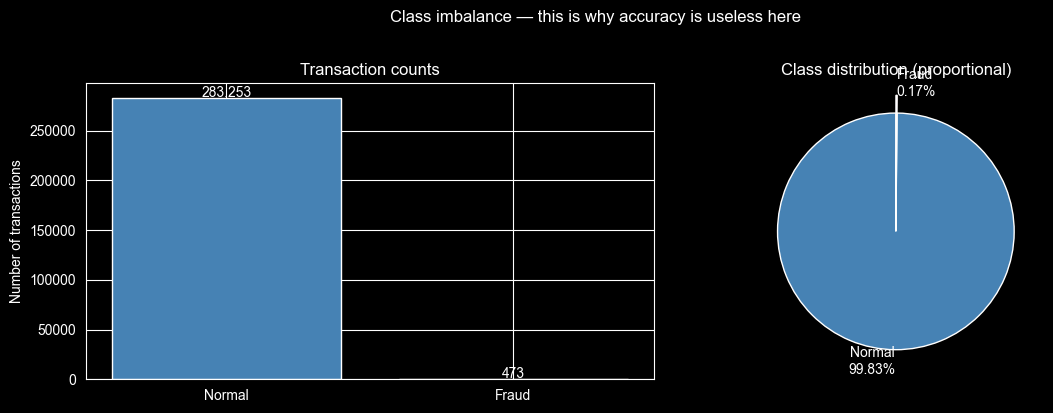

In [6]:
# ─── CLASS DISTRIBUTION ────────────────────────────────────────────────────
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)
print("\nClass percentages:")
print(class_pct.round(4))

# OUTPUT:
# 0    284315   (99.8268%)
# 1       492   (0.1727%)

# Visualize it — two charts side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1: Raw counts (shows how extreme the imbalance is)
axes[0].bar(['Normal', 'Fraud'],
            [class_counts[0], class_counts[1]],
            color=['steelblue', 'crimson'])
axes[0].set_title('Transaction counts')
axes[0].set_ylabel('Number of transactions')
for i, v in enumerate([class_counts[0], class_counts[1]]):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

# Chart 2: Percentage (zoomed in to see the fraud slice)
axes[1].pie([class_counts[0], class_counts[1]],
            labels=['Normal\n99.83%', 'Fraud\n0.17%'],
            colors=['steelblue', 'crimson'],
            startangle=90,
            explode=(0, 0.15))   # Pop the fraud slice out
axes[1].set_title('Class distribution (proportional)')

plt.suptitle('Class imbalance — this is why accuracy is useless here', y=1.02)
plt.tight_layout()
plt.show()

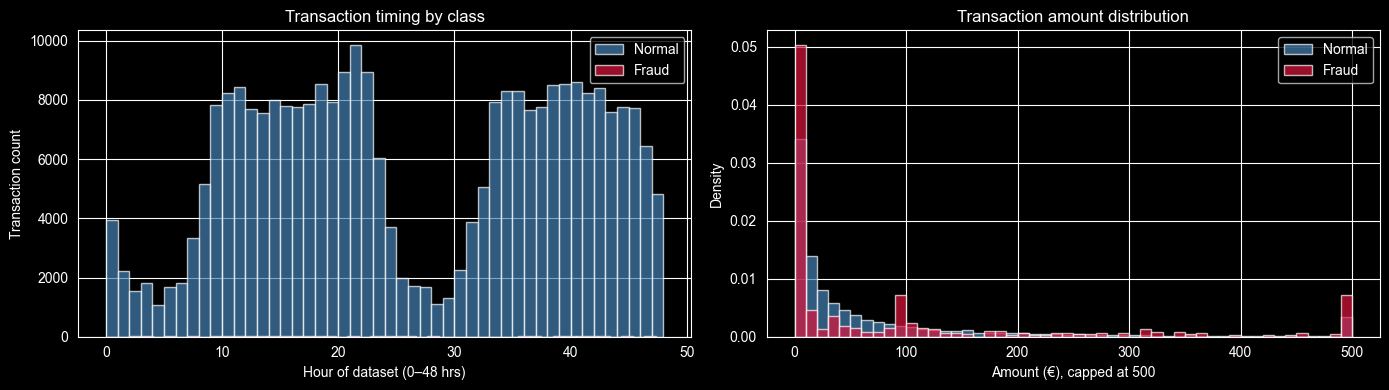

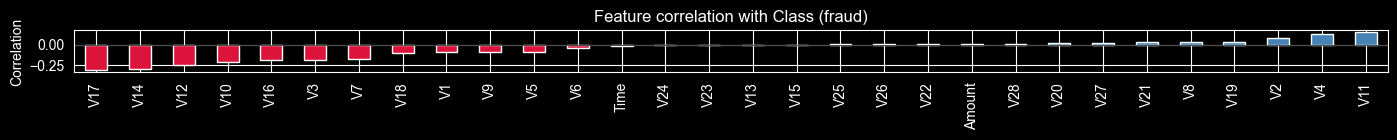


Top 5 features most correlated with fraud:
V17   0.3135
V14   0.2934
V12   0.2507
V10   0.2070
V16   0.1872
Name: Class, dtype: float64


In [7]:
# ─── TIME ANALYSIS ─────────────────────────────────────────────────────────
# Do frauds happen at certain times of day? (Time column = seconds since start)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

normal_time = df[df['Class'] == 0]['Time'] / 3600   # Convert to hours
fraud_time  = df[df['Class'] == 1]['Time'] / 3600

axes[0].hist(normal_time, bins=48, color='steelblue', alpha=0.7, label='Normal')
axes[0].hist(fraud_time,  bins=48, color='crimson',   alpha=0.7, label='Fraud')
axes[0].set_xlabel('Hour of dataset (0–48 hrs)')
axes[0].set_ylabel('Transaction count')
axes[0].set_title('Transaction timing by class')
axes[0].legend()

# ─── AMOUNT DISTRIBUTION BY CLASS ──────────────────────────────────────────
normal_amt = df[df['Class'] == 0]['Amount']
fraud_amt  = df[df['Class'] == 1]['Amount']

axes[1].hist(normal_amt.clip(upper=500), bins=50,
             color='steelblue', alpha=0.7, label='Normal', density=True)
axes[1].hist(fraud_amt.clip(upper=500),  bins=50,
             color='crimson',   alpha=0.7, label='Fraud',  density=True)
axes[1].set_xlabel('Amount (€), capped at 500')
axes[1].set_ylabel('Density')
axes[1].set_title('Transaction amount distribution')
axes[1].legend()

plt.tight_layout()
plt.show()


# ─── CORRELATION HEATMAP ────────────────────────────────────────────────────
# Which V features are most correlated with fraud?
# This tells you which features the model will lean on most
plt.figure(figsize=(14, 1.5))
corr_with_target = df.corr()['Class'].drop('Class').sort_values()
corr_with_target.plot(kind='bar',
                       color=['crimson' if v < 0 else 'steelblue'
                              for v in corr_with_target])
plt.title('Feature correlation with Class (fraud)')
plt.axhline(0, color='black', linewidth=0.5)
plt.ylabel('Correlation')
plt.tight_layout()
plt.show()

# Features with strongest negative correlation (like V17, V14, V12)
# mean: when those values are high, fraud is LESS likely
# Features with strongest positive correlation (like V4, V11)
# mean: when those values are high, fraud is MORE likely
print("\nTop 5 features most correlated with fraud:")
print(corr_with_target.abs().sort_values(ascending=False).head())

In [8]:
# ─── END-OF-PHASE SUMMARY ──────────────────────────────────────────────────
# Always document what you found before moving to preprocessing

print("=" * 50)
print("PHASE 1 SUMMARY")
print("=" * 50)
print(f"Total transactions:  {len(df):,}")
print(f"Normal:              {class_counts[0]:,}  ({class_pct[0]:.2f}%)")
print(f"Fraud:               {class_counts[1]:,}  ({class_pct[1]:.4f}%)")
print(f"Missing values:      {df.isnull().sum().sum()}")
print(f"Duplicate rows:      {df.duplicated().sum()}")
print(f"Features:            {df.shape[1] - 1}  (V1-V28 + Time + Amount)")
print(f"Amount range:        €{df['Amount'].min():.2f} – €{df['Amount'].max():.2f}")
print(f"\nKey finding: Dataset is severely imbalanced.")
print(f"SMOTE will be required in Phase 3 to fix this.")
print(f"V14, V17, V12 are likely the most predictive features.")

PHASE 1 SUMMARY
Total transactions:  283,726
Normal:              283,253  (99.83%)
Fraud:               473  (0.1667%)
Missing values:      0
Duplicate rows:      0
Features:            30  (V1-V28 + Time + Amount)
Amount range:        €0.00 – €25691.16

Key finding: Dataset is severely imbalanced.
SMOTE will be required in Phase 3 to fix this.
V14, V17, V12 are likely the most predictive features.
